## Your first Neural Network in PyTorch – An Introduction

#### Associated Jupyter Notebook and Code

In  this notebook, we will build a simple fully connected Neural Network, and a simple Convolutional Neural Network to classify the MNIST dataset of hand-written digits.
You will learn:
- to read image files in Python and transform them into the same format (Channels, Width, Height)
- to download and read the openly available MNIST dataset for training Neural Networks for handwritten digit detection
- the fundamentals of machine learning and Neural Networks (see accompanying slides). How do they work? What components are necessary?
- how to use PyTorch to implement a Neural Network
- if the trained model is able to correctly identifies your handwritten postal code

### First Steps:

#### 1. Create a Python environment for this project (we will do it together)

See the instructions on the Githubs readme.

#### 2. Write your postal code digit-by-digit in Paint 

The goal of this workshop is to create a program that can read handwritten images of the German Postal code.

To make pre-processing easier, we save every digit individually as a single image. Please open paint and write every digit of your (or a made up) postal code in an individual file and save it as a .png on your drive.

In [1]:
# import all necessary packages
import numpy as np
import pandas as pd
import xarray as xr
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import os

#### How to read image files in Python

In [2]:
# There are several ways to load an image in Python (often depending on the file type)
# We will use the Image function from the Pillow package to load the .png image of first letter of the postal code

#### !!! You might need to set the path in Image.open("PATH") to the images yourself, according to the path were you actually store them !!!

image = np.asarray(Image.open(Path.cwd() / "postal_code" / "Postal_code_1.png").convert("L"))
pixels = np.array(image, copy=True)

# Now, pixels already is a 2D numpy array. 
# We can use xarray to further transform it into a xarray-type, with additional metadata
image = xr.DataArray(
    pixels,
    dims=("y", "x"),
    name="brightness",
)

#### Inspecting the data

In [3]:
# It is always a good idea to inspect the data before using it.
# We will therefore first have a look at how our image is represented in Python.
# Since the variable pixels contains a numpy object, we can use the .shape function on numpy object to print the dimensionality.
# The dimensions show us the number of pixels in x and y, which correspond to width and height of the image

print(pixels.shape)

(438, 598)


In [6]:
# We now use a loop to load all the files in a list

# For this, we will first create a function for loading an image:

def load_img(path):
    image = np.asarray(Image.open(path).convert("L"))
    pixels = np.array(image, copy=True)
    
    mask_255 = np.where(pixels == 255)
    mask_0 = np.where(pixels == 0)
    pixels[mask_255] = 0
    pixels[mask_0] = 255
    
    return pixels

# Now, we need a list of all images to load.
# We use os.listdir to list all files in the given directory:
init_path = Path.cwd() / "postal_code" 
list_of_pngs = os.listdir(init_path)
print(list_of_pngs)

# the loop itself
list_with_imgs = []
for png in list_of_pngs:
    if png.endswith(".png"):
        list_with_imgs.append(load_img(init_path / png))

['nine.png', 'Postal_code_1.png', 'Postal_code_3.png', 'Postal_code_3_end.png', 'Postal_code_3_v2.png', 'Postal_code_5.png']


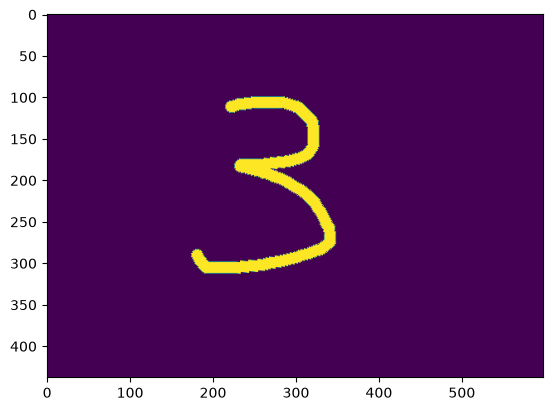

In [7]:
plt.imshow(list_with_imgs[3])

#### Now we will load existing data for training a model that learns a good classification

PyTorch has several datasets for training and testing models stored for you to download.

One very famous dataset is the so called MNIST data, which includes thousands of handwritten images of digits and their correspoding real digits as labels.

This dataset is ideal to train our model, which can then hopefully identify our Paint-written digits.

In [9]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# after importing the necessary package modules, loading the data is as simple as:
train_data = MNIST(
    root="data",
    train=True, #This tells the downloader that we only want to have the training data
    download=True,
    transform=ToTensor(),
)

In [10]:
# We now have a look at the data
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [11]:
# in total, the training data contains 60.000 entries
len(train_data)

60000

In [12]:
# How does one entry look like?
print("The type of the first entry is:", type(train_data[0]))
print("The length of the first entry is:", len(train_data[0]))

The type of the first entry is: <class 'tuple'>
The length of the first entry is: 2


#### Every entry of this list contains a tuple, that in itself also has two entries

In [14]:
# The two entries of the tuple are the image, and the corresponding digit.
# We extract them into individual variables and print the images dimensions and the corresponding digit:
image, label = train_data[0]
print("The image has a dimension of:", image.shape)
print("The image contains the digit:", label)

The image has a dimension of: torch.Size([1, 28, 28])
The image contains the digit: 5


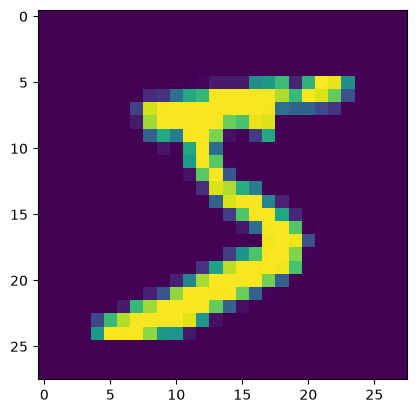

In [15]:
# We can now plot the image
plt.imshow(image[0,:,:])

In [16]:
# One more note regarding data types:

# The image from the MNIST downloader is a "torch.Tensor"
# This is a PyTorch datatype, which is very interchangable with numpy.arrays:
print(type(image))
print(type(image.numpy()))

<class 'torch.Tensor'>
<class 'numpy.ndarray'>


##### PyTorch is a very powerful package for creating customized Neural Networks easily

We will now implement a simple neural network for image classification.

For functioning Neural Networks, we aways need:

- Training and Validation data
- An architecture
- A loss function 
- An Optimizer that tunes our weights according to the loss function

#### The data

In [17]:
################################################
################## The Data ####################
################################################

# Training data is available from above: 
train_data = train_data

# We can download the validation data in the same fashion:
val_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

PyTorch offers another important advantage: It makes it easy to train in batches, which are equally sized "buckets" of training data. 

Each batch is processed at once , increasing the training speed but potentially results in less generalized results.

In [25]:
# Loading the data in batches is easy:

# We first import the DataLoader module from torch
from torch.utils.data import DataLoader

# We now create a DataLoader object, which allows separates the data into the "buckets", over which we will iterate for x epochs
train_loader = DataLoader(
    train_data,
    batch_size=64,   # this is equal to the number of training data in each "bucket"
    shuffle=True,    # with shuffle = True, samples are randomly put together into a "bucket" at every epoch. Better generalization.
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False, # For validation, we can turn shuffle to False, because we do not train the model anymore -> no influence on the model
)

In [18]:
################################################
################## The Model ###################
################################################

import torch
from torch import nn

# We first create a simple fully connected network.
# The input is our image, the output is a vector with 10 entries, 
# each entry has a so called logit value corresponding to a digit.

class MNISTClassifier_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Flatten(),               # we start with a 2D tensor with 28x28 -> this flattens it into 1D with dimensions: (Batch_Size, 784)
            nn.Linear(28 * 28, 128),    # In the first layer, we go from 784 to 128 in a fully connected fashion
            nn.ReLU(),                  # We use the ReLu() activation function
            nn.Linear(128, 10),         # We use a second fully connected layer to go from 128 dimensions to 10. Thes ten output dimensions are our classes for the ten digits
        )

    def forward(self, x):
        
        network_result = self.network(x) # We call the defined architecture 
        return network_result

## About nn.Sequential

As mentioned in the slides, nn.Sequential acts like a container that executes all modules one after another.
This helps in the forward function, where we now only need to call a single function: the one including nn.Sequential.

We could however, call everything individually, not using nn.Sequential. 
This is shown below:

In [ ]:
# Here, we truly call everything one after another and look at all the individual dimensions.
# Notice, how and where the input and output dimensions come into play: 


# Our original input data
batch_1 = next(iter(train_loader))

print("Images:", batch_1[0].shape)
print("Labels:", batch_1[1].shape)


In [ ]:
# the Flattening
flatten_img = nn.Flatten()
flatten_result = flatten_img(batch_1[0])

print("Shape:",flatten_result.shape)
print(flatten_result[0,:])

In [ ]:

# The fully connected layer 
hidden_layer = nn.Linear(28 * 28, 128)
h_layer_result = hidden_layer(flatten_result)

print("Shape:", h_layer_result.shape)
print(h_layer_result[0,:])

In [ ]:
# The activation function. Notice how all negative values are now 0.
activation_func = nn.ReLU()
h_layer_relu = activation_func(h_layer_result)

print("Shape:", h_layer_relu.shape)
print(h_layer_relu[0,:])

In [ ]:
# The ouput layer with 10 classes
output_layer = nn.Linear(128,10)
out_layer_result = output_layer(h_layer_relu)

print("Shape:",out_layer_result.shape)
print(out_layer_result[0,:])

In [ ]:

# This is what it would look like without the nn.Sequential container:
# Define everything individually
flatten_img = nn.Flatten()
hidden_layer = nn.Linear(28 * 28, 128)
activation_func = nn.ReLU()
output_layer = nn.Linear(128,10)

# call it individually (this would be in the forward function)
flatten_result = flatten_img(batch_1[0])
h_layer_result = hidden_layer(flatten_result)
h_layer_relu = activation_func(h_layer_result)
out_layer_result = output_layer(h_layer_relu)

print("Shape:",out_layer_result.shape)
print(out_layer_result[0,:])

# Or, in a single go (shape should be identical, result as well):
out_layer_result = output_layer(activation_func(hidden_layer(flatten_img(batch_1[0]))))
print("Shape:",out_layer_result.shape)
print(out_layer_result[0,:])

In [ ]:

# This is what it would look like without the nn.Sequential container:
# Define everything individually
flatten_img = nn.Flatten()
hidden_layer = nn.Linear(28 * 28, 128)
activation_func = nn.ReLU()
output_layer = nn.Linear(128,10)

# call it individually (this would be in the forward function)
flatten_result = flatten_img(batch_1[0])
h_layer_result = hidden_layer(flatten_result)
h_layer_relu = activation_func(h_layer_result)
out_layer_result = output_layer(h_layer_relu)

print("Shape:",out_layer_result.shape)
print(out_layer_result[0,:])

# or, in a single go:
out_layer_result = output_layer(activation_func(hidden_layer(flatten_img(batch_1[0]))))
print("Shape:",out_layer_result.shape)
print(out_layer_result[0,:])

## We continue with the model and its training!

In [20]:
# We can now create an object of our model.
# This will be used to get the actual prediction below.
model = MNISTClassifier_MLP()

In [21]:
# We can now have a look at the total number of model parameters.

# These are the total number of parameters.
total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Total parameters: {total_params:,}")

# To have a look at only the trainable parameters, we do:
trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
print(f"Trainable parameters: {trainable_params:,}")

#This comes from:
#Linear(784 → 128): 784 × 128 + 128 = 100,480
#Linear(128 → 10):  128 × 10 + 10   =   1,290
#Total:                               101,770

Total parameters: 101,770
Trainable parameters: 101,770


#### The loss function

In [23]:
################################################
############## The Loss Function ###############
################################################

# We can either implement the loss function of choice ourselves
def our_cross_entropy(logits_output, targets):
    digits_to_proba = nn.softmax(logits_output) #Apply a softmax to our logits
    batch_indices = torch.arange(logits_output.shape[0])
    
    correct_probabilities = digits_to_proba[batch_indices, targets]
    losses = -torch.log(correct_probabilities)
    return losses.mean()


# Or we can use an existing PyTorch function for it.
# PyTorch has a lot of basic loss funcitons available.
# The one we need is also there:
loss_function = nn.CrossEntropyLoss()

#### The optimizer

In [26]:
################################################
################ The Optimizer #################
################################################

# Different optimizers are available in PyTorch
# We choose to use Adam, which is, for now, the most commonly used optimizer.
# In the accompanying slides, Stochastic Gradient Descent is explained. This is also available using torch.optim.SGD(). 

# The optimizer needs the models parameters and, very importantly, the learning rate 'lr'. 
# This can and should be tuned according to your problem. 1e-3 is often a good place to start.

# !!! IMPORTANT !!!
# After calling this, do not initialize your model again by accident

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#### The training


Now everything is defined, lets put it together in a loop that trains all samples for a given number of epochs.

!!! IMPORTANT !!!

During training, we always need 1. optimizer.zero_grad() -> 2. loss.backward() -> 3. optimizer.step()

This corresponds to 
1. Set the gradients from the previous batch to 0 before calculating gradients for the current batch
2. Calculate the gradients via backpropagation and add them to each tuneable parameters .grad value
3. Update the models training parameters according to the gradients (and the fixed learning rate of te optimizer)

The sequencing is important here, because you need to make sure to calculate the gradients on empty .grad values. 

In [27]:
################################################
############## Training the Model ##############
################################################

# the number of epochs
epochs = 5

################################################
############# The actual training ##############
################################################

for epoch in range(epochs):
    
    print(f"Start Epoch {epoch+1}")
    
    ################################################################################################
    ################################################################################################
    
    # Training
    # turn on training mode
    model.train()            
    # We measure the losses development over the epochs to see if it really goes down          
    total_loss = 0.0                    

    for images, labels in train_loader: # iterate over every batch in the train_loader and retrieve images and labels 
        
        # Set the gradients from the previous batch to 0 before calculating gradients for the current batch
        optimizer.zero_grad()  
                 
        # Call the model. Input: images (see forward function of model); Output: Vector with 10 entries
        prediction = model(images)      
           
        # Call the loss function. nn.CrossEntropyLoss() takes predictions first, true values second.
        loss = loss_function(prediction,labels)  
          
        # Calculate the gradients via backpropagation                     
        loss.backward()     
        
        # Update the models training parameters according to the gradients            
        optimizer.step()     
                   
        # Update the loss with the loss from this batch. Displaying purposes only
        total_loss += loss.item()       

    # Average the loss for this epoch
    average_loss = total_loss / len(train_loader) 

    ################################################################################################
    ################################################################################################
    
     # Evaluationon the validation data
    model.eval() # turn on evaluation mode
    correct = 0  # track the number of correctly assigned digits
    total = 0    # # track the total number of samples 
    validation_loss = 0.0 

    with torch.no_grad():
        for images, labels in val_loader:
            
            logits = model(images)                          # run the trained model on the validation data
            
            predictions = logits.argmax(dim=1)              # This returns the digit with the highest assigned logit value -> this is our final prediction

            loss = loss_function(logits,labels)
            validation_loss += loss.item()  
                        
            correct += (predictions == labels).sum().item() # Save correctly predicted digits of the batch 
            total += labels.size(0)                         # Save total size of the batch

    # Calculate average loss per epoch for validation samples
    average_val_loss = validation_loss / len(val_loader)
    # Calculate the proportion of correctly predicted digits 
    accuracy = correct / total     
    
    # Print the loss of each epoch. We want them to go down
    print(f"Epoch {epoch + 1}/{epochs}, training loss: {average_loss:.4f}, validation loss: {average_val_loss:.4f}, validation accuracy: {accuracy:.2%}") 

Start Epoch 1
Epoch 1/5, training loss: 0.3404, validation loss: 0.1769, validation accuracy: 94.80%
Start Epoch 2
Epoch 2/5, training loss: 0.1550, validation loss: 0.1306, validation accuracy: 96.18%
Start Epoch 3
Epoch 3/5, training loss: 0.1083, validation loss: 0.1025, validation accuracy: 96.87%
Start Epoch 4
Epoch 4/5, training loss: 0.0829, validation loss: 0.0888, validation accuracy: 97.37%
Start Epoch 5
Epoch 5/5, training loss: 0.0650, validation loss: 0.0802, validation accuracy: 97.51%


In [31]:
# We then save the models weights for future usage
torch.save(model.state_dict(), Path.cwd() / "models" / "mnist_model.pth")

## EXERCISE 
### Hyperparameter might have an influence on the results. 

There are several hyperparameters that can be changed. These include: 
- the number of hidden layers (deeper networks are often better)
- the number of hidden dimensions at each layer
- the batch size used (smaller batch sizes might generalize better)
- the learning rate (too large is not good, too small also)
- the number of epochs (do more epochs help reducing the validation loss further?)

Alss, keep track different results:
- How long did model training take?
- How is the performance on Train and Validation set?

In [ ]:
# YOUR CODE HERE

### Convolutional Neural Networks are often the more natural choice for images

We therefore prepare a second architecture using Con2d modules.

We will also deepen the network and use two containers with convolutional layers, as well as one output layer that flattens and applies a fully connected network.

Due to it being deeper and using different kinds of operations, it will probably take a little longer to train.

In [53]:
import torch
from torch import nn

class MNISTClassifier_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.first_conv = nn.Sequential(              
            nn.Conv2d(1, 32, (3,3), stride=1, padding=1),    # Conv2d uses a 2D window to look at all pixels surrounding the investigated pixel. 
                                                             # It needs the number of input channels, the number of output channels and the kernes size 
                                                             # As necessary inputs nn.Conv2D(Input_channels, output channels, window size).
                                                             # In our case: we have a single grey value input channel, 
                                                             # an arbitrary number of ouput channels (we can choose this), 
                                                             # and will use a kerne that looks at all directly neighboring pixels (3,3).
            nn.ReLU(),
            nn.MaxPool2d((2,2)),                             # Max-Pooling is used to reduce the width and height dimensions of the input image. 
            )
        self.second_conv = nn.Sequential(              
            nn.Conv2d(32, 64, (3,3), stride=1, padding=1),    
            nn.ReLU(),
            nn.MaxPool2d((2,2)),            
        )
        
        # Here comes the fully connected network. Its similar to before, 
        # just the number of input dimensions changes to the number of channels x width x height
        # The output of the last layer are again our classes
        self.conv_to_output = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        
        # in this forward function, we need to call every nn.Sequential container to make sure we actually use all parts of the architecture
        
        first_layer = self.first_conv(x)
        second_layer = self.second_conv(first_layer)
        network_result = self.conv_to_output(second_layer) # We call the defined network 
        
        return network_result

In [54]:
# After defining the model class, we need to create an object of the model:
model_cnn = MNISTClassifier_CNN()

In [35]:
# We again look at the parameters

total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 421,642


In [57]:
# We need to define loss function and optimizer 
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

# Train
epochs = 5

for epoch in range(epochs):
    model_cnn.train()                       # turn on training mode
    total_loss = 0.0                    # initialize loss for display purposes

    for images, labels in train_loader: # iterate over every batch in the train_loader. The larger the batch size, the lower the number of iterations

        optimizer.zero_grad()           # Set the gradients from the previous batch to 0 before calculating gradients for the current batch

        logits = model_cnn(images)          # Call the model. Input: images (see forward function of model); Output: Vector with 10 entries
        
        loss = loss_function(logits,    # Call the loss function. nn.CrossEntropyLoss() takes predictions first, true values second.
                             labels)

        loss.backward()                 # Calculate the gradients via backpropagation
        optimizer.step()                # Update the models training parameters according to the gradients

        total_loss += loss.item()       # Update the loss with the loss from this batch. Displaying purposes only

    average_loss = total_loss / len(train_loader) # after every batch of an epoch is run through, we average the summarized loss
    
     # Evaluationon the validation data
    model_cnn.eval() # turn on evaluation mode
    correct = 0  # track the number of correctly assigned digits
    total = 0    # # track the total number of samples 
    validation_loss = 0.0 

    with torch.no_grad():
        for images, labels in val_loader:
            
            logits = model_cnn(images)                          # run the trained model on the validation data
            
            predictions = logits.argmax(dim=1)              # This returns the digit with the highest assigned logit value -> this is our final prediction

            loss = loss_function(logits,labels)
            validation_loss += loss.item()  
                        
            correct += (predictions == labels).sum().item() # Save correctly predicted digits of the batch 
            total += labels.size(0)                         # Save total size of the batch

    # Calculate average loss per epoch for validation samples
    average_val_loss = validation_loss / len(val_loader)
    # Calculate the proportion of correctly predicted digits 
    accuracy = correct / total     
    
    # Print the loss of each epoch. We want them to go down
    print(f"Epoch {epoch + 1}/{epochs}, training loss: {average_loss:.4f}, validation loss: {average_val_loss:.4f}, validation accuracy: {accuracy:.2%}") 

Epoch 1/5, training loss: 0.0423, validation loss: 0.0310, validation accuracy: 98.98%
Epoch 2/5, training loss: 0.0299, validation loss: 0.0286, validation accuracy: 98.99%
Epoch 3/5, training loss: 0.0216, validation loss: 0.0307, validation accuracy: 99.07%
Epoch 4/5, training loss: 0.0193, validation loss: 0.0271, validation accuracy: 99.15%
Epoch 5/5, training loss: 0.0160, validation loss: 0.0376, validation accuracy: 98.81%


#### Now we apply this model to our real world data. 

We already loaded the images, but they have a different shape and datatype (remember, quite big 2D images as a numpy array)

In [37]:
# We adapt the loop to automatically give us numpys in the wanted dimensions:
def load_img(path):
    image = np.asarray(Image.open(path).convert("L"))
    pixels = np.array(image, copy=True)
    
    mask_255 = np.where(pixels == 255)
    mask_0 = np.where(pixels == 0)
    pixels[mask_255] = 0
    pixels[mask_0] = 255
    
    # we will use the xarray package to resize the images
    # Therefor, we create an xarray object from the numpy pixels image
    xr_image = xr.DataArray(
    pixels,
    dims=("y", "x"),
    name="brightness",
    )
    
    # image has dimensions ("y", "x")
    xr_image = xr_image.assign_coords(
        y=np.arange(xr_image.sizes["y"]),
        x=np.arange(xr_image.sizes["x"]),
    )

    target_y = np.linspace(xr_image.y.min().item(), xr_image.y.max().item(), 28)
    target_x = np.linspace(xr_image.x.min().item(), xr_image.x.max().item(), 28)

    # Here, we do the actual resizing using bicubic interpolation
    resized = xr_image.interp(
        y=target_y,
        x=target_x,
        method="cubic",
    )

    return resized

# Now, we need a list of all images to load.
# We use os.listdir to list all files in the given directory (you might need to adapt this directory path!):
init_path = Path.cwd() / "postal_code" 
list_of_pngs = os.listdir(init_path)
print(list_of_pngs)

# the loop itself
imgs_mnist_size = []
for png in list_of_pngs:
    if png.endswith(".png"):
        
        numpy_img = np.array(load_img(init_path / png))
        numpy_img = np.float32(numpy_img)
        
        # Convert 0–255 values to 0–1
        numpy_img /= numpy_img.max()
        tensor_img = torch.from_numpy(numpy_img)
        # Grayscale image: [28, 28] -> [1, 1, 28, 28]
        tensor_img = tensor_img.unsqueeze(0).unsqueeze(0)
        
        imgs_mnist_size.append(tensor_img)

['mnist_model.pth', 'nine.png', 'Postal_code_1.png', 'Postal_code_3.png', 'Postal_code_3_end.png', 'Postal_code_3_v2.png', 'Postal_code_5.png']


In [38]:
# lets look at the shape of one tensor:
imgs_mnist_size[0].shape

# -> looks good, since (Batch,Channel,Width,Height) is all there. Lets try to use it as input!

torch.Size([1, 1, 28, 28])

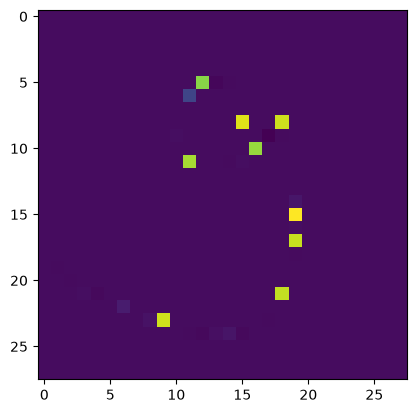

In [48]:
plt.imshow(imgs_mnist_size[0][0,0,:,:])

In [59]:
# With the fully connected model:

for dig in imgs_mnist_size:
    logits = model(dig)  
    predictions = logits.argmax(dim=1)
    print(predictions[0])

tensor(3)
tensor(1)
tensor(3)
tensor(9)
tensor(5)
tensor(5)


In [58]:
# With the updated CNN model:

for dig in imgs_mnist_size:
    logits = model_cnn(dig)  
    predictions = logits.argmax(dim=1)
    print(predictions[0])

tensor(1)
tensor(1)
tensor(3)
tensor(3)
tensor(3)
tensor(5)


### Results

- How is the overall performance of both models on the paint data? 
- Is the CNN model any better?
- Have a look at the interpolated 28x28 paint images. Where do the models misclassify? Why do you think this is? 